# COE Statistical Analysis - Data Exploration & Cleaning

## Step 1: Load and Inspect All Datasets

This notebook explores the structure of each dataset, identifies data quality issues, and performs initial descriptive statistics.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set style for visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

# Define data path
data_path = Path('../')
print(f"Data path: {data_path}")
print(f"\nAvailable CSV files:")
for f in sorted(data_path.glob('*.csv')):
    print(f"  - {f.name}")

Data path: ..

Available CSV files:
  - COEBiddingResultsPrices.csv
  - ConsumerPriceIndex.csv
  - HouseholdIncome.csv
  - RetailSalesIndex.csv


## 1.1 Load COE Bidding Results (Primary Dataset)

In [2]:
# Load COE pricing data
coe_df = pd.read_csv(data_path / 'COEBiddingResultsPrices.csv')

print(f"COE Bidding Data Shape: {coe_df.shape}")
print(f"\nFirst 5 rows:")
print(coe_df.head())
print(f"\nData Types:")
print(coe_df.dtypes)
print(f"\nMissing Values:")
print(coe_df.isnull().sum())
print(f"\nBasic Statistics:")
print(coe_df.describe())

COE Bidding Data Shape: (1915, 7)

First 5 rows:
     month  bidding_no vehicle_class  quota bids_success bids_received  \
0  2010-01           1    Category A   1152         1145          1342   
1  2010-01           1    Category B    687          679           883   
2  2010-01           1    Category C    173          173           265   
3  2010-01           1    Category D    373          365           509   
4  2010-01           1    Category E    586          567          1011   

   premium  
0    18502  
1    19190  
2    19001  
3      889  
4    19889  

Data Types:
month              str
bidding_no       int64
vehicle_class      str
quota            int64
bids_success       str
bids_received      str
premium          int64
dtype: object

Missing Values:
month            0
bidding_no       0
vehicle_class    0
quota            0
bids_success     0
bids_received    0
premium          0
dtype: int64

Basic Statistics:
        bidding_no        quota        premium
count  1915

In [3]:
# Parse month column and create properly formatted date
coe_df['month'] = pd.to_datetime(coe_df['month'], format='%Y-%m')
coe_df['year'] = coe_df['month'].dt.year

print(f"Date range: {coe_df['month'].min()} to {coe_df['month'].max()}")
print(f"\nVehicle Classes:")
print(coe_df['vehicle_class'].value_counts())
print(f"\nBidding cycles per class per year:")
print(coe_df.groupby(['year', 'vehicle_class']).size().head(20))

Date range: 2010-01-01 00:00:00 to 2026-03-01 00:00:00

Vehicle Classes:
vehicle_class
Category A    383
Category B    383
Category C    383
Category D    383
Category E    383
Name: count, dtype: int64

Bidding cycles per class per year:
year  vehicle_class
2010  Category A       24
      Category B       24
      Category C       24
      Category D       24
      Category E       24
2011  Category A       24
      Category B       24
      Category C       24
      Category D       24
      Category E       24
2012  Category A       24
      Category B       24
      Category C       24
      Category D       24
      Category E       24
2013  Category A       24
      Category B       24
      Category C       24
      Category D       24
      Category E       24
dtype: int64


## 1.2 Visualize COE Price Trends

Plot saved as 01_coe_trends.png


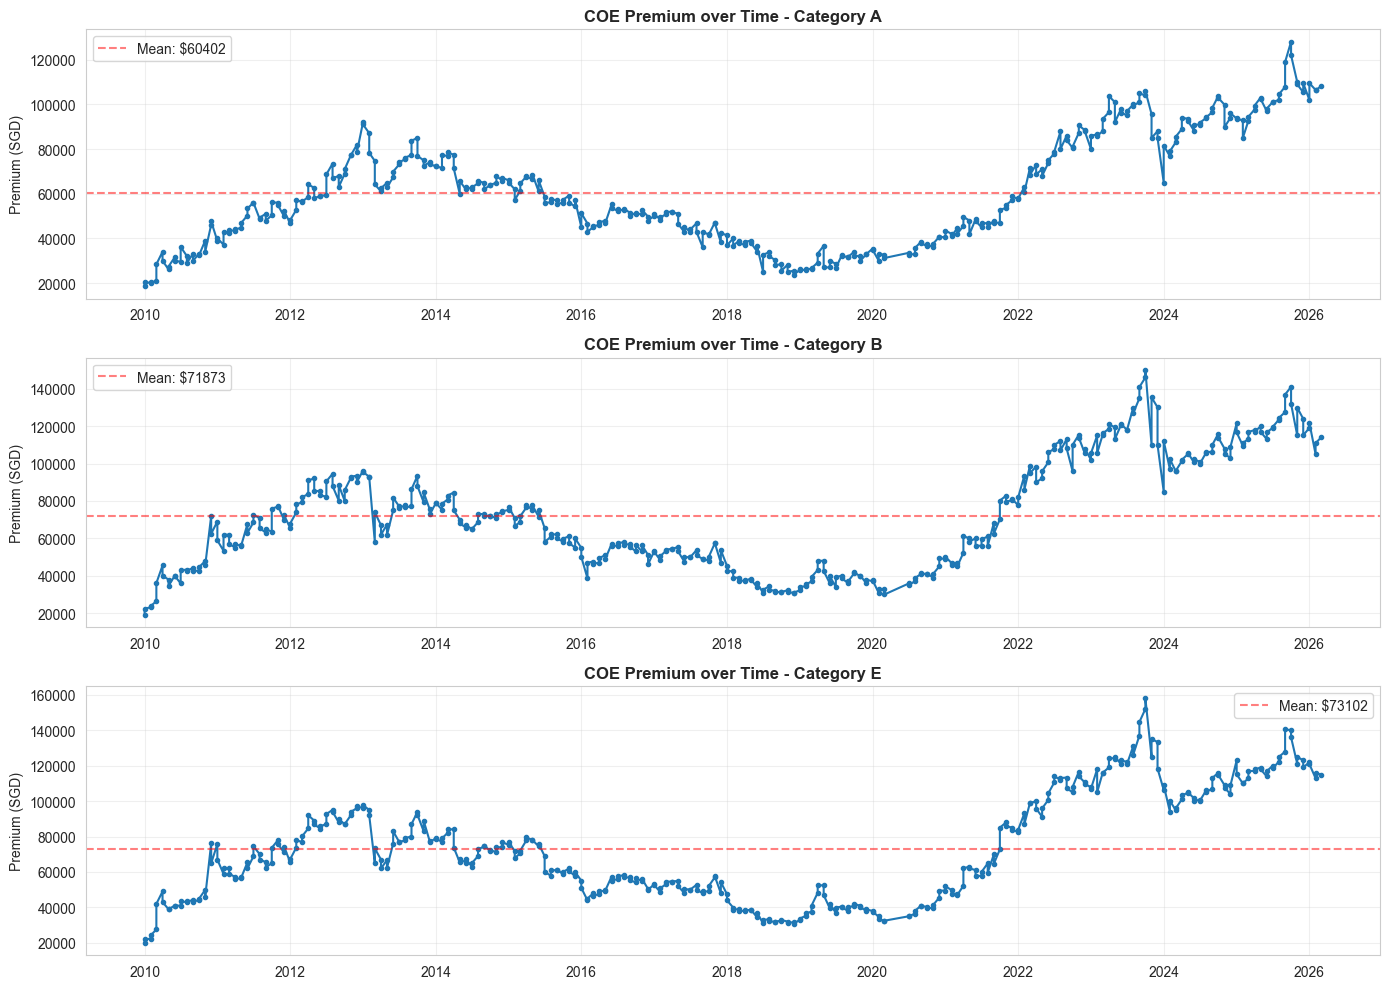

In [4]:
# Plot COE premium (price) trends by vehicle class
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

for idx, vclass in enumerate(['Category A', 'Category B', 'Category E']):
    class_data = coe_df[coe_df['vehicle_class'] == vclass].sort_values('month')
    axes[idx].plot(class_data['month'], class_data['premium'], marker='o', markersize=3, linewidth=1.5)
    axes[idx].set_title(f'COE Premium over Time - {vclass}', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Premium (SGD)')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].axhline(y=class_data['premium'].mean(), color='r', linestyle='--', alpha=0.5, label=f'Mean: ${class_data["premium"].mean():.0f}')
    axes[idx].legend()

plt.tight_layout()
plt.savefig('../plots/01_coe_trends.png', dpi=150, bbox_inches='tight')
print("Plot saved as 01_coe_trends.png")
plt.show()

## 1.3 Load and Inspect Household Income Data

In [5]:
# Load household income (needs cleaning - SingStat wide format)
income_df = pd.read_csv(data_path / 'HouseholdIncome.csv')

print(f"Household Income Shape: {income_df.shape}")
print(f"\nFirst few rows (showing first 8 columns):")
print(income_df.iloc[:5, :8])
print(f"\nColumn names (first 10):")
print(income_df.columns[:10].tolist())
print(f"\nTotal columns: {len(income_df.columns)}")
print(f"\nFirst column content (row index):")
print(income_df.iloc[:10, 0])

Household Income Shape: (105, 27)

First few rows (showing first 8 columns):
                                          Unnamed: 0  Unnamed: 1  Unnamed: 2  \
0                                  Theme: Households         NaN         NaN   
1                          Subject: Household Income         NaN         NaN   
2          Topic: Key Indicators On Household Income         NaN         NaN   
3  Table Title: Key Indicators On Household Emplo...         NaN         NaN   
4                                                NaN         NaN         NaN   

   Unnamed: 3  Unnamed: 4  Unnamed: 5  Unnamed: 6  Unnamed: 7  
0         NaN         NaN         NaN         NaN         NaN  
1         NaN         NaN         NaN         NaN         NaN  
2         NaN         NaN         NaN         NaN         NaN  
3         NaN         NaN         NaN         NaN         NaN  
4         NaN         NaN         NaN         NaN         NaN  

Column names (first 10):
['Unnamed: 0', 'Unnamed: 1', 'Un

## 1.4 Load and Inspect CPI Data

In [6]:
# Load Consumer Price Index (wide format)
cpi_df = pd.read_csv(data_path / 'ConsumerPriceIndex.csv')

print(f"CPI Shape: {cpi_df.shape}")
print(f"\nFirst few rows (first 8 columns):")
print(cpi_df.iloc[:5, :8])
print(f"\nFirst column (index/row labels):")
print(cpi_df.iloc[:10, 0])
print(f"\nTotal columns: {len(cpi_df.columns)}")

CPI Shape: (255, 783)

First few rows (first 8 columns):
                                          Unnamed: 0 Unnamed: 1 Unnamed: 2  \
0                            Theme: Economy & Prices        NaN        NaN   
1                      Subject: Consumer Price Index        NaN        NaN   
2                  Topic: Consumer Price Index (CPI)        NaN        NaN   
3  Table Title: Consumer Price Index (CPI), 2024 ...        NaN        NaN   
4                                                NaN        NaN        NaN   

  Unnamed: 3 Unnamed: 4 Unnamed: 5 Unnamed: 6 Unnamed: 7  
0        NaN        NaN        NaN        NaN        NaN  
1        NaN        NaN        NaN        NaN        NaN  
2        NaN        NaN        NaN        NaN        NaN  
3        NaN        NaN        NaN        NaN        NaN  
4        NaN        NaN        NaN        NaN        NaN  

First column (index/row labels):
0                              Theme: Economy & Prices
1                        Subjec

## 1.5 Load and Inspect Retail Sales Index

In [7]:
# Load Retail Sales Index (wide format)
rsi_df = pd.read_csv(data_path / 'RetailSalesIndex.csv')

print(f"Retail Sales Index Shape: {rsi_df.shape}")
print(f"\nFirst few rows (first 8 columns):")
print(rsi_df.iloc[:5, :8])
print(f"\nFirst column (index/row labels):")
print(rsi_df.iloc[:10, 0])
print(f"\nTotal columns: {len(rsi_df.columns)}")

Retail Sales Index Shape: (48, 494)

First few rows (first 8 columns):
                                          Unnamed: 0 Unnamed: 1 Unnamed: 2  \
0                                    Theme: Industry        NaN        NaN   
1                                  Subject: Services        NaN        NaN   
2                    Topic: Retail Sales Index (RSI)        NaN        NaN   
3  Table Title: Retail Sales Index, (2025 = 100),...        NaN        NaN   
4                                                NaN        NaN        NaN   

  Unnamed: 3 Unnamed: 4 Unnamed: 5 Unnamed: 6 Unnamed: 7  
0        NaN        NaN        NaN        NaN        NaN  
1        NaN        NaN        NaN        NaN        NaN  
2        NaN        NaN        NaN        NaN        NaN  
3        NaN        NaN        NaN        NaN        NaN  
4        NaN        NaN        NaN        NaN        NaN  

First column (index/row labels):
0                                      Theme: Industry
1                

## 1.6 Investigate M810361 (Unknown Dataset)

In [ ]:
# Check if M810361 file exists and what it contains
m81_path = data_path / 'M810361.csv'
if m81_path.exists():
    m81_df = pd.read_csv(m81_path)
    print(f"M810361 Shape: {m81_df.shape}")
    print(f"\nFirst 10 rows:")
    print(m81_df.head(10))
    print(f"\nColumn names:")
    print(m81_df.columns.tolist())
    print(f"\nUnique values in first column:")
    print(m81_df.iloc[:, 0].unique())
else:
    print("M810361.csv not found - check if it was converted from Excel properly")

## Summary & Next Steps

Once you review the data structure above, we should:

1. **Clean SingStat files** (HouseholdIncome, CPI, RSI) - unpivot from wide to long format
2. **Align time periods** - ensure all datasets share a common date range
3. **Create unified analysis dataset** - merge COE with economic factors
4. **Begin RQ5 analysis** - seasonality in COE prices
5. **Start correlation analysis** (RQ1) - COE vs income, CPI, RSI, quota